In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Loading Excel file & printing sheet names
xls = pd.ExcelFile("../data/raw/Region_TEX.xlsx")
print(xls.sheet_names)

['Published Hourly Data', 'Published Daily Data', 'Hourly Charts', 'Daily Charts', 'Notes', 'BA Names']


In [ ]:
# Loading the data from the 'Published Hourly Data' sheet and saving it as a CSV file
df = pd.read_excel("../data/raw/Region_TEX.xlsx", sheet_name='Published Hourly Data')
# Convert Excel to CSV (run once when preparing raw data)
# df.to_csv("../data/raw/texas_demand.csv", index=False) already done, so ignoring this line

In [3]:
df_demand = pd.read_csv('../data/raw/texas_demand.csv')

In [ ]:
df_demand.head()

,Region,UTC time,Local date,Hour,Local time,Time zone,Demand forecast,Demand,Net generation,Total interchange,...,CO2 Emissions: OIL,CO2 Emissions: Other,CO2 Emissions Generated,CO2 Emissions Imported,CO2 Emissions Exported,CO2 Emissions Consumed,Positive Generation,Consumed Electricity,CO2 Emissions Intensity for Generated Electricity,CO2 Emissions Intensity for Consumed Electricity
0,TEX,2015-07-01 06:00:00,2015-07-01,1,2015-07-01 01:00:00,Central,39708.0,37456.0,37462.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TEX,2015-07-01 07:00:00,2015-07-01,2,2015-07-01 02:00:00,Central,37338.0,35119.0,35124.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TEX,2015-07-01 08:00:00,2015-07-01,3,2015-07-01 03:00:00,Central,35697.0,33638.0,33642.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,TEX,2015-07-01 09:00:00,2015-07-01,4,2015-07-01 04:00:00,Central,34772.0,32798.0,32805.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,TEX,2015-07-01 10:00:00,2015-07-01,5,2015-07-01 05:00:00,Central,34773.0,32805.0,32812.0,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df_demand.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93840 entries, 0 to 93839
Data columns (total 66 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Region                                             93840 non-null  object 
 1   UTC time                                           93840 non-null  object 
 2   Local date                                         93840 non-null  object 
 3   Hour                                               93840 non-null  int64  
 4   Local time                                         93840 non-null  object 
 5   Time zone                                          93840 non-null  object 
 6   Demand forecast                                    93696 non-null  float64
 7   Demand                                             93744 non-null  float64
 8   Net generation                                     93744 non-null  float64
 9   Total 

In [6]:
df_demand.describe()

,Hour,Demand forecast,Demand,Net generation,Total interchange,Sum (NG),NG: COL,NG: NG,NG: NUC,NG: OIL,...,CO2 Emissions: OIL,CO2 Emissions: Other,CO2 Emissions Generated,CO2 Emissions Imported,CO2 Emissions Exported,CO2 Emissions Consumed,Positive Generation,Consumed Electricity,CO2 Emissions Intensity for Generated Electricity,CO2 Emissions Intensity for Consumed Electricity
count,93840.000000,93696.000000,93744.000000,93744.000000,93503.000000,67512.000000,67440.000000,67440.000000,67440.000000,0.0,...,0.0,67440.000000,67440.000000,67485.000000,67485.000000,67415.000000,67512.000000,67488.000000,67440.000000,67415.000000
mean,12.500117,46510.727801,46308.653866,46258.503243,-48.434392,48424.964643,8019.980560,21157.691667,4686.871382,NaN,...,NaN,91.719513,17380.795729,87.914430,34.077159,17437.789066,48453.579482,48547.241628,0.787191,0.787763
std,6.922427,11393.706442,11175.601942,11093.809098,307.258739,11161.004486,2532.819862,9313.748860,624.557966,NaN,...,NaN,32.432053,5858.416491,125.827006,51.095986,5921.754622,11169.697246,11233.864291,0.187675,0.187729
min,1.000000,24071.000000,24763.000000,24688.000000,-1211.000000,0.000000,1933.000000,411.000000,2442.000000,NaN,...,NaN,17.457632,3959.160278,0.000000,0.000000,3975.742466,0.000000,-348.000000,0.194371,0.202131
25%,6.750000,38075.000000,38078.000000,38085.000000,-200.000000,40270.000000,6095.000000,14076.750000,3914.000000,NaN,...,NaN,67.146069,12995.696687,0.000000,0.000000,13005.854818,40270.000000,40319.000000,0.651991,0.652379
50%,12.500000,44251.000000,44158.000000,44133.000000,-6.000000,46262.000000,7827.000000,20260.000000,5000.000000,NaN,...,NaN,89.646663,16855.960887,37.508738,8.763299,16898.447407,46282.500000,46341.000000,0.799365,0.799833
75%,18.250000,53054.250000,52736.000000,52664.000000,124.000000,54772.250000,9798.000000,27207.000000,5104.000000,NaN,...,NaN,112.964914,21202.298258,115.220470,50.947948,21269.830761,54855.250000,54935.000000,0.932868,0.933561
max,25.000000,87055.000000,85544.000000,85000.000000,1212.000000,84999.000000,15319.000000,51156.000000,5157.000000,NaN,...,NaN,246.832496,34822.480434,718.000818,503.885919,35097.559319,84999.000000,85543.000000,1.255504,1.255504


In [7]:
# Taking only the relevant columns
cols = ['Demand forecast','Demand','Local time']
demand = df_demand[cols]

In [8]:
# Renaming columns for clarity
demand = demand.rename(columns={'Demand forecast': 'forecast_MW', 'Demand': 'demand_MW', 'Local time': 'timestamp'})
demand['timestamp'].min(), demand['timestamp'].max()

('2015-07-01 01:00:00', '2026-03-15 00:00:00')

In [9]:
demand['timestamp'] = pd.to_datetime(demand['timestamp']) # Convert timestamp to datetime format

In [10]:
# Filter the demand data to include only records from 2018 to 2023
demand = demand[(demand['timestamp'] >= '2018-01-01') & (demand['timestamp'] < '2024-01-01')]
demand['timestamp'].min(), demand['timestamp'].max()

(Timestamp('2018-01-01 00:00:00'), Timestamp('2023-12-31 23:00:00'))

In [11]:
demand.shape 
# 52584 rows, it means we have 6 years of hourly data (365*24*6 = 52560, close enough), so we can proceed with this dataset. 
#The small difference in rows could be due to leap years, there doesn't seem to be missing timestamps

(52584, 3)

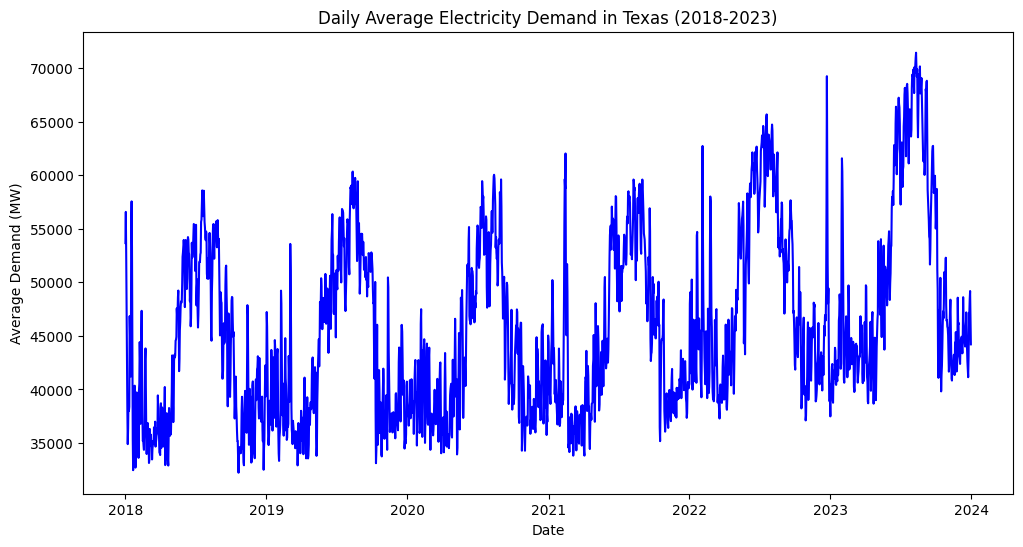

In [12]:
# Daily average demand plot
daily_mean = (
    demand.groupby(demand['timestamp'].dt.date)['demand_MW'].mean()
)

plt.figure(figsize=(12, 6))
plt.plot(daily_mean.index, daily_mean.values, color='blue')
plt.xlabel('Date')
plt.ylabel('Average Demand (MW)')
plt.title('Daily Average Electricity Demand in Texas (2018-2023)')
plt.show()

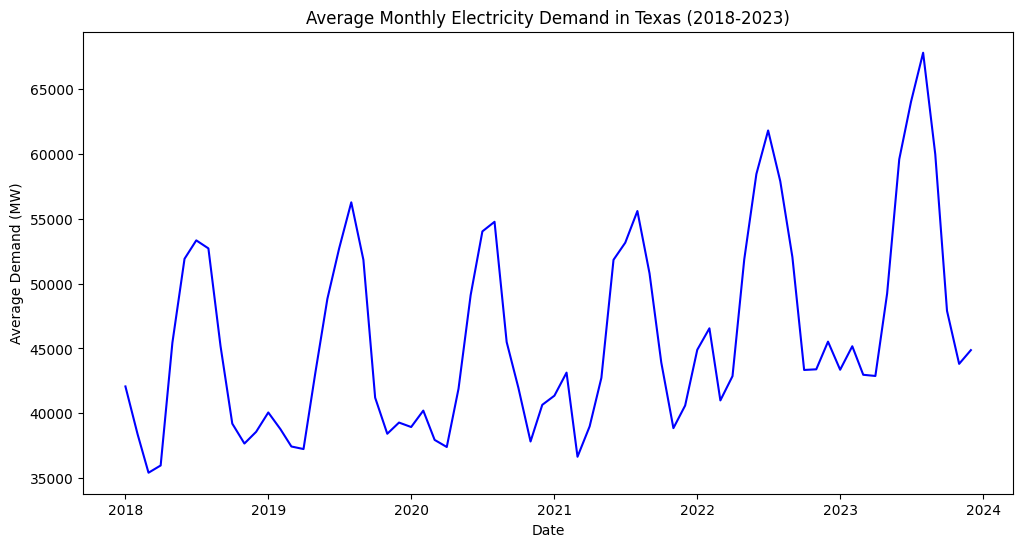

In [13]:
# Monthly average demand plot
monthly_mean = (
    demand.groupby(demand['timestamp'].dt.to_period('M'))['demand_MW'].mean()
)

plt.figure(figsize=(12, 6))
plt.plot(monthly_mean.index.to_timestamp(), monthly_mean.values, color='blue')
plt.xlabel('Date')
plt.ylabel('Average Demand (MW)')
plt.title('Average Monthly Electricity Demand in Texas (2018-2023)')
plt.show()

In [14]:
# Loading weather data from the Open-Meteo API
url = "https://archive-api.open-meteo.com/v1/archive?latitude=29.76&longitude=-95.36&start_date=2018-01-01&end_date=2023-12-31&hourly=temperature_2m"

df_weather = pd.read_json(url)

In [15]:
weather = pd.DataFrame({
    "timestamp": df_weather["hourly"]["time"],
    "temperature": df_weather["hourly"]["temperature_2m"]
})

In [16]:
weather.head()

,timestamp,temperature
0,2018-01-01T00:00,8.3
1,2018-01-01T01:00,7.8
2,2018-01-01T02:00,7.1
3,2018-01-01T03:00,6.2
4,2018-01-01T04:00,4.8


In [17]:
weather.tail()

,timestamp,temperature
52579,2023-12-31T19:00,20.6
52580,2023-12-31T20:00,21.2
52581,2023-12-31T21:00,21.5
52582,2023-12-31T22:00,21.2
52583,2023-12-31T23:00,18.6


In [18]:
weather.shape

(52584, 2)

In [19]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52584 entries, 0 to 52583
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   timestamp    52584 non-null  object 
 1   temperature  52584 non-null  float64
dtypes: float64(1), object(1)
memory usage: 821.8+ KB


In [20]:
weather["timestamp"] = pd.to_datetime(weather["timestamp"]) # Convert timestamp to datetime format
weather["timestamp"] = weather["timestamp"].dt.tz_localize(None)

In [ ]:
# Converting to CSV (run once when preparing raw data)
# weather.to_csv("../data/raw/houston_weather.csv", index=False) # Save the weather data to a CSV file 
# Already done, so commenting out the above line

In [21]:
weather.isnull().sum() 

timestamp      0
temperature    0
dtype: int64

In [22]:
demand.isnull().sum()

forecast_MW    96
demand_MW      48
timestamp       0
dtype: int64

In [23]:
demand['timestamp'].equals(weather['timestamp']) # Check if timestamps match between demand and weather datasets

False

In [24]:
demand['timestamp'].head()

21960   2018-01-01 00:00:00
21961   2018-01-01 01:00:00
21962   2018-01-01 02:00:00
21963   2018-01-01 03:00:00
21964   2018-01-01 04:00:00
Name: timestamp, dtype: datetime64[ns]

In [25]:
weather['timestamp'].head()

0   2018-01-01 00:00:00
1   2018-01-01 01:00:00
2   2018-01-01 02:00:00
3   2018-01-01 03:00:00
4   2018-01-01 04:00:00
Name: timestamp, dtype: datetime64[ns]

In [26]:
demand['timestamp'].tail()


74539   2023-12-31 19:00:00
74540   2023-12-31 20:00:00
74541   2023-12-31 21:00:00
74542   2023-12-31 22:00:00
74543   2023-12-31 23:00:00
Name: timestamp, dtype: datetime64[ns]

In [27]:
weather['timestamp'].tail()

52579   2023-12-31 19:00:00
52580   2023-12-31 20:00:00
52581   2023-12-31 21:00:00
52582   2023-12-31 22:00:00
52583   2023-12-31 23:00:00
Name: timestamp, dtype: datetime64[ns]

In [28]:
diff = weather['timestamp'] - demand['timestamp'] 
diff.value_counts()

timestamp
914 days 23:00:00    19723
915 days 00:00:00    10901
Name: count, dtype: int64

In [29]:
demand['timestamp'].dt.tz
weather['timestamp'].dt.tz # Sanity check, both are timezone naive (no timezone info)

In [30]:
demand['timestamp'].diff().value_counts() # demand has 12 problem rows
# 0 days 00:00:00 would mean 6 duplicate timestamps & 0 days 02:00:00 could mean 6 missing timestamps, we will investigate this further in the next notebook.
# Mostly due to daylight saving time changes

timestamp
0 days 01:00:00    52571
0 days 02:00:00        6
0 days 00:00:00        6
Name: count, dtype: int64

In [31]:
weather['timestamp'].diff().value_counts() 
# weather has 0 problem rows, all timestamps are exactly 1 hour apart, so we can be confident that there are no missing or duplicate timestamps in the weather data.

timestamp
0 days 01:00:00    52583
Name: count, dtype: int64

In [32]:
demand = demand.set_index('timestamp').sort_index() # Set timestamp as index and sort by it, this will make it easier to handle time series data in the next steps

# remove duplicate DST hour
demand = demand.groupby(level=0).mean()

# create missing hour
demand = demand.asfreq('H')

# fill missing values
demand = demand.interpolate('time')

C:\Users\Pratik\AppData\Local\Temp\ipykernel_17376\1330457346.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  demand = demand.asfreq('H')


In [33]:
demand.isna().sum() # Now we have 0 missing values in the demand data, we can proceed with this dataset for modeling.

forecast_MW    0
demand_MW      0
dtype: int64

In [34]:
weather = weather.set_index('timestamp').sort_index() # Set timestamp as index and sort by it, this will make it easier to handle time series data in the next steps

In [35]:
demand.index.to_series().diff().value_counts() 
# Final sanity check before merging

timestamp
0 days 01:00:00    52583
Name: count, dtype: int64

In [36]:
weather.index.to_series().diff().value_counts()
# Both demand and weather data have 0 missing or duplicate timestamps, we can confidently merge them on the timestamp index without worrying about misalignment issues.

timestamp
0 days 01:00:00    52583
Name: count, dtype: int64

In [37]:
data = demand.join(weather) # Merge demand and weather data on timestamp index, this will be our final dataset for modeling

In [38]:
data.head() # Check the first few rows of the merged dataset to ensure everything looks good

,forecast_MW,demand_MW,temperature
timestamp,,,
2018-01-01 00:00:00,45764.0,50863.0,8.3
2018-01-01 01:00:00,47834.0,50587.0,7.8
2018-01-01 02:00:00,48313.0,50650.0,7.1
2018-01-01 03:00:00,49513.0,50737.0,6.2
2018-01-01 04:00:00,48663.0,51021.0,4.8


In [39]:
data.info() # Check the info of the final merged dataset to confirm that we have 52584 rows and 3 columns (demand_MW, forecast_MW, temperature) with no missing values.

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52584 entries, 2018-01-01 00:00:00 to 2023-12-31 23:00:00
Freq: h
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   forecast_MW  52584 non-null  float64
 1   demand_MW    52584 non-null  float64
 2   temperature  52584 non-null  float64
dtypes: float64(3)
memory usage: 1.6 MB


In [40]:
data.describe() # Check the statistical summary of the final merged dataset to understand the distribution of demand and temperature values.

,forecast_MW,demand_MW,temperature
count,52584.000000,52584.000000,52584.000000
mean,46033.037825,45857.592538,21.039413
std,10826.467471,10576.296820,7.674092
min,26391.000000,27371.000000,-10.900000
25%,38319.000000,38301.750000,16.000000
50%,43278.500000,43285.000000,22.500000
75%,51607.500000,51307.750000,26.500000
max,86895.000000,85432.000000,41.700000


In [41]:
data.shape
# Confirm we have 52584 rows and 3 columns in the final dataset, this means we have successfully merged the demand and weather data without losing any rows.

(52584, 3)

In [42]:
data.isnull().sum() # Final check to confirm we have 0 missing values in the final merged dataset.

forecast_MW    0
demand_MW      0
temperature    0
dtype: int64

In [43]:
data.index.name = "timestamp"

In [44]:
data.to_csv("../data/processed/demand_weather_merged.csv", index=True) # Save the final merged dataset to a CSV file for use in the next steps of the project.